In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


In [3]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


   STEP 1 - Raw Dataset Loaded
Original columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Shape: (200, 5)

   STEP 2 - Preprocessing
Cleaned columns: ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score', 'Gender_Encoded']

First 10 rows:
 CustomerID Gender  Age  Annual_Income  Spending_Score  Gender_Encoded
          1   Male   19             15              39               1
          2   Male   21             15              81               1
          3 Female   20             16               6               0
          4 Female   23             16              77               0
          5 Female   31             17              40               0
          6 Female   22             17              76               0
          7 Female   35             18               6               0
          8 Female   23             18              94               0
          9   Male   64             19               3               1


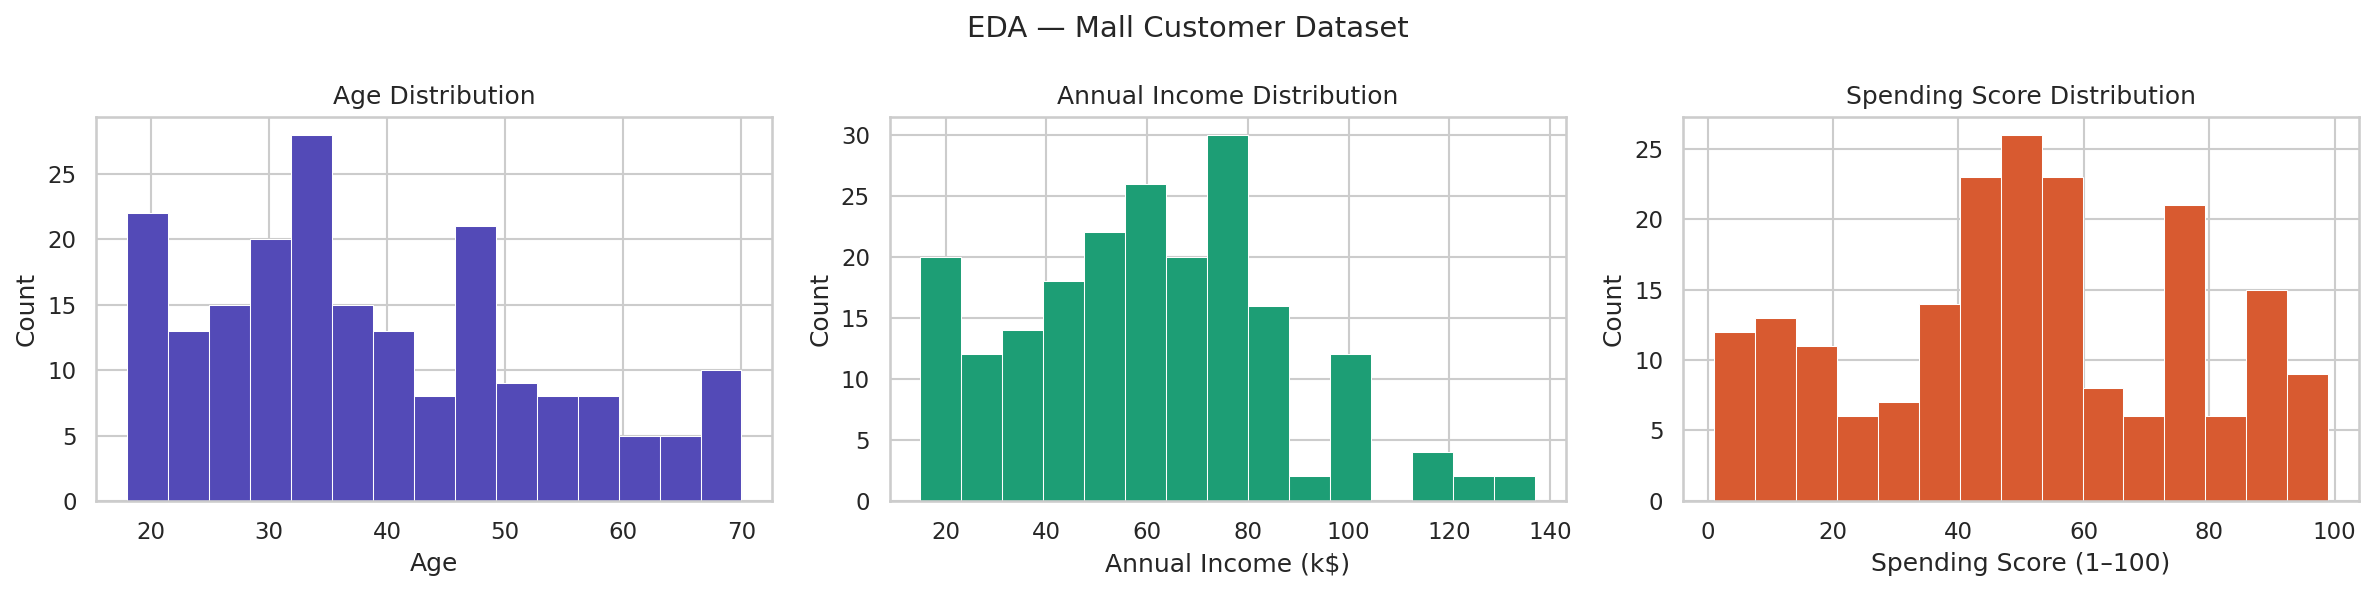


Saved: eda_distributions.png


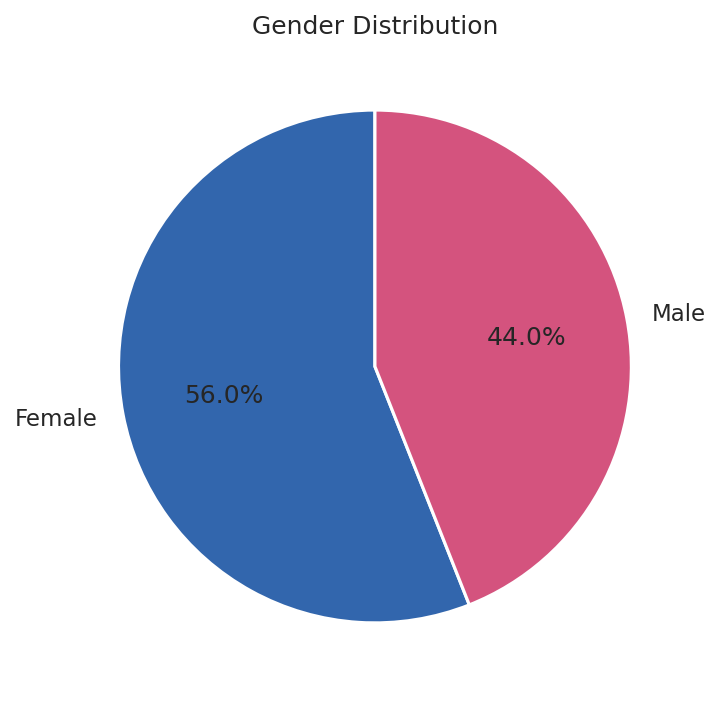

Saved: gender_distribution.png


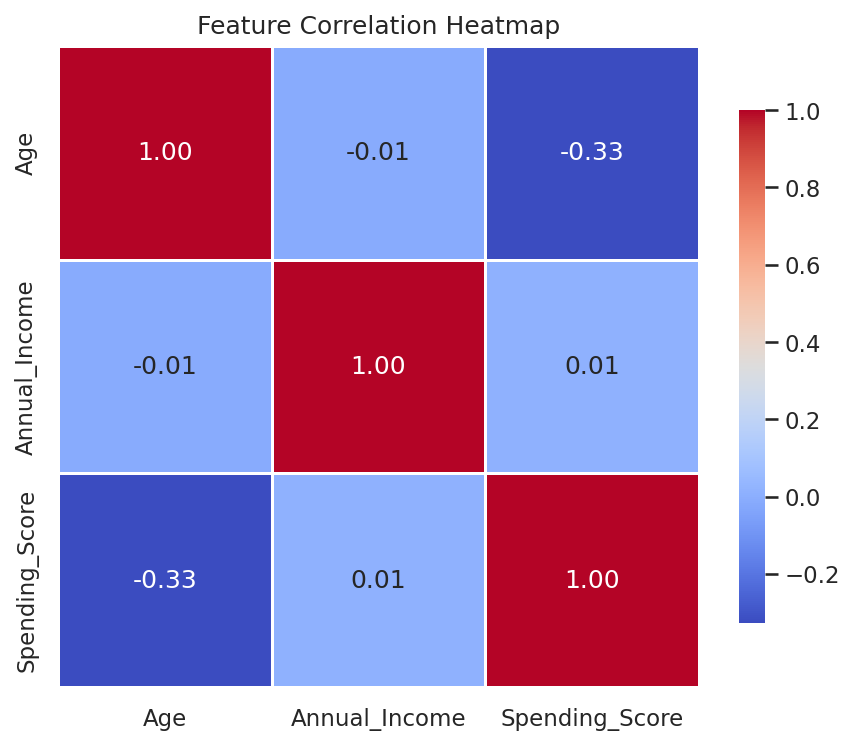

Saved: correlation_heatmap.png


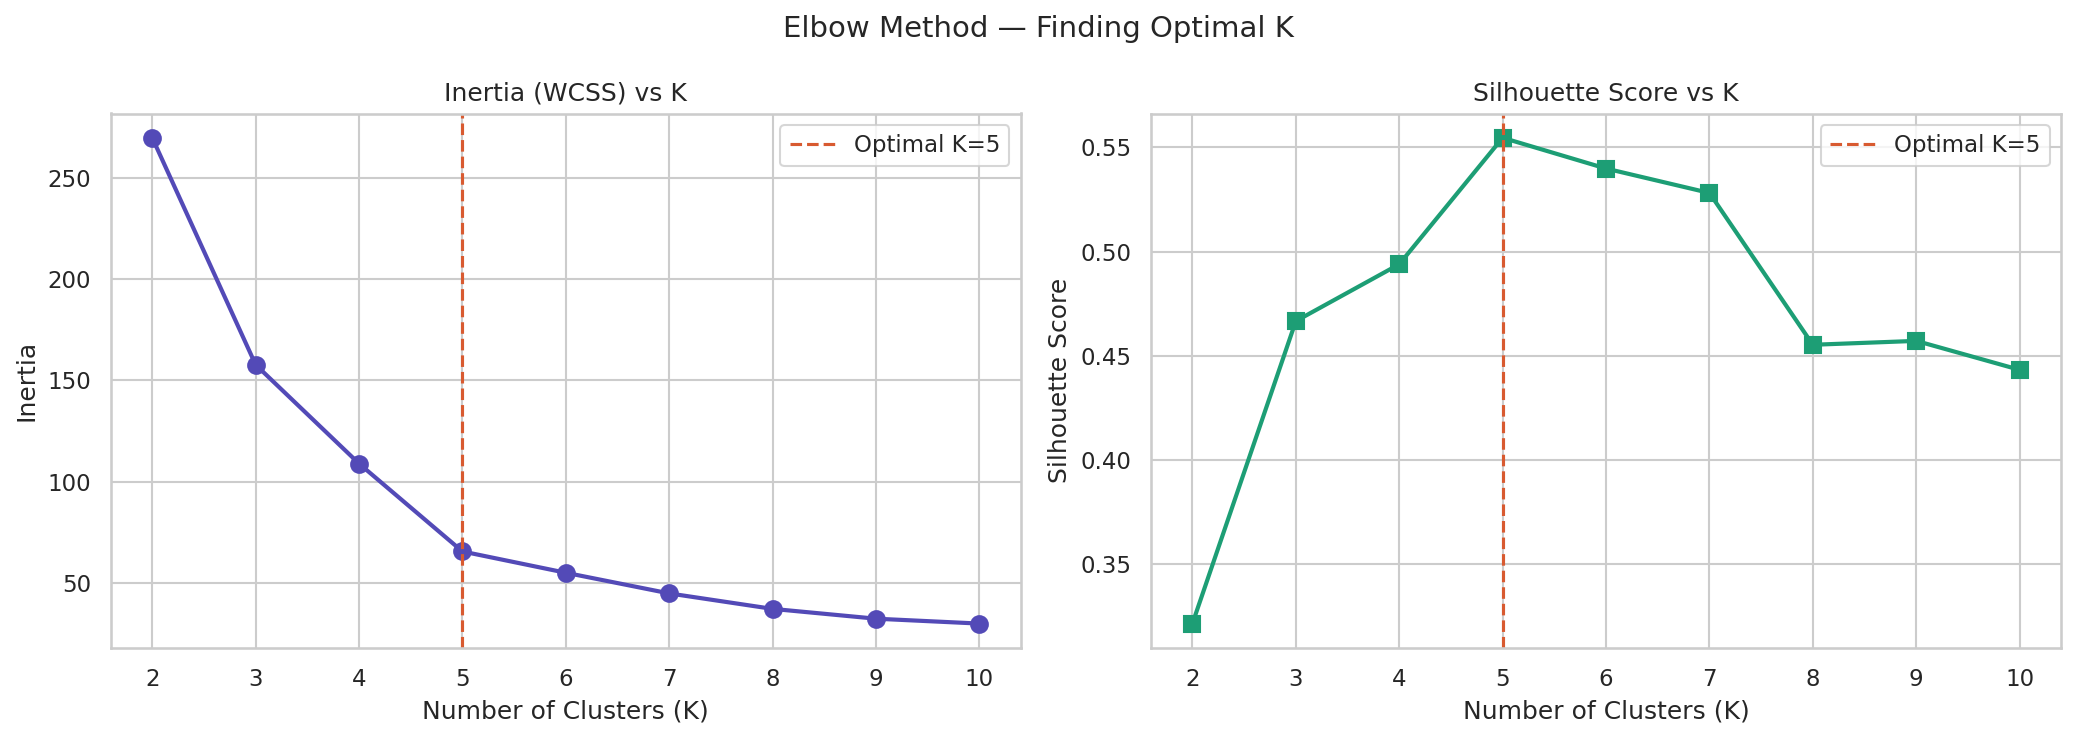

Saved: elbow_method.png

Best K by Silhouette Score : 5
Using K=5 (standard for Mall Customer dataset)

   STEP 5 - K-Means Applied (K=5)
Cluster Centroids (original scale):
   Income_Center  Spend_Center                       Segment
0           55.3          49.5             Average Customers
1           86.5          82.1             Premium Loyalists
2           25.7          79.4      Low Income High Spenders
3           88.2          17.1  High Income Careful Spenders
4           26.3          20.9               Budget Browsers

Segment Distribution:
Segment
Average Customers               81
Premium Loyalists               39
High Income Careful Spenders    35
Budget Browsers                 23
Low Income High Spenders        22


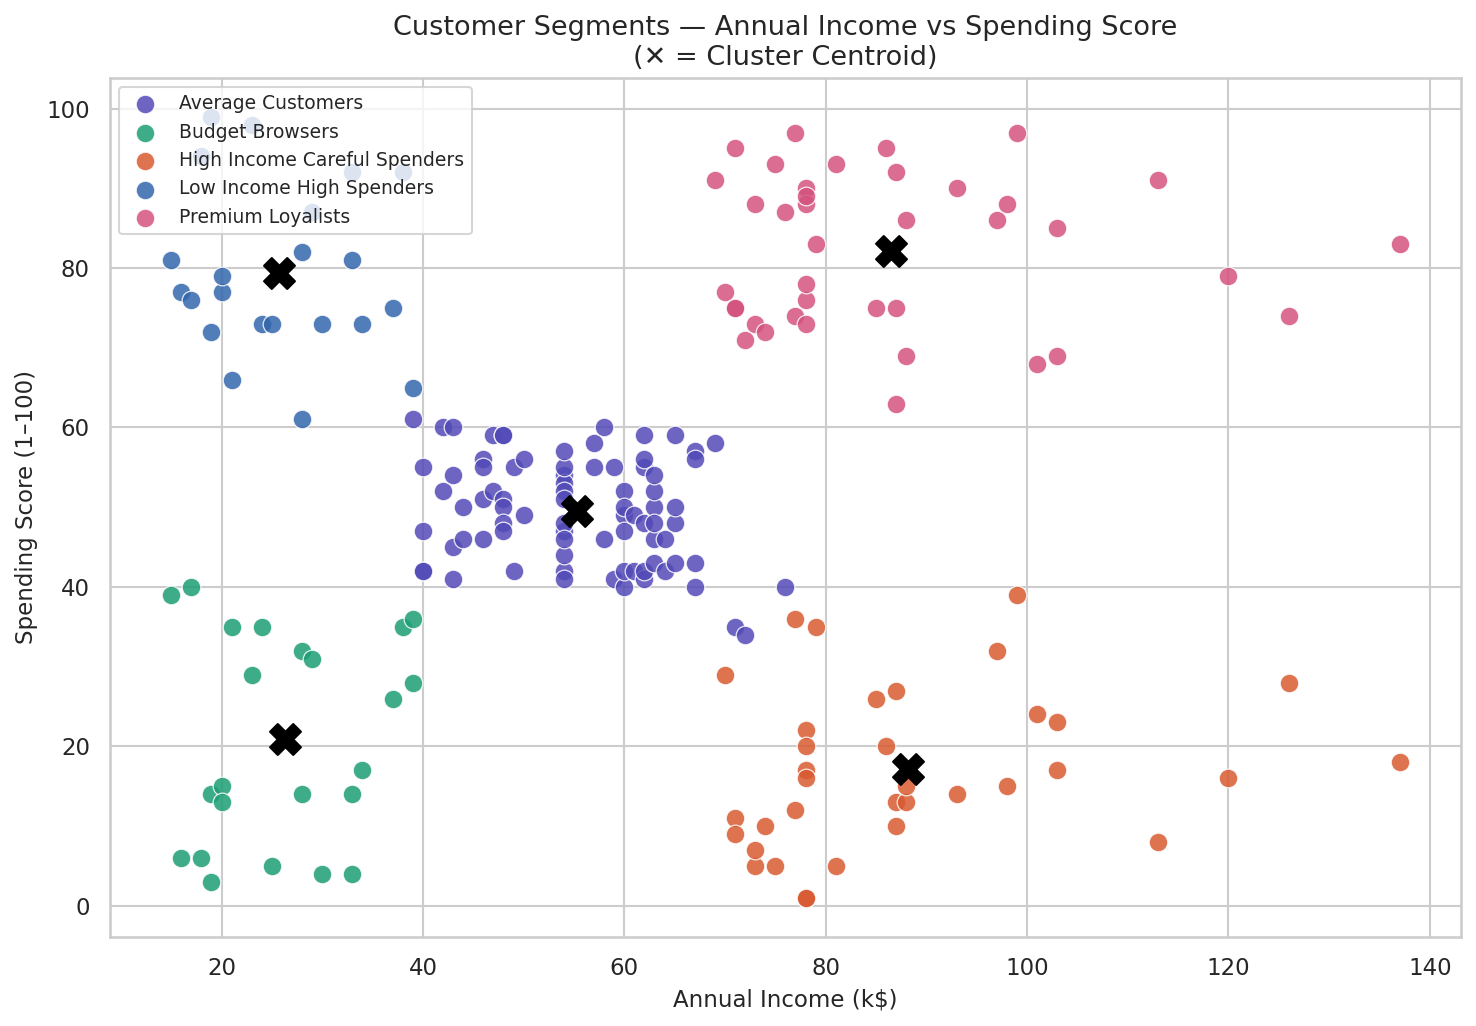

Saved: cluster_scatter.png


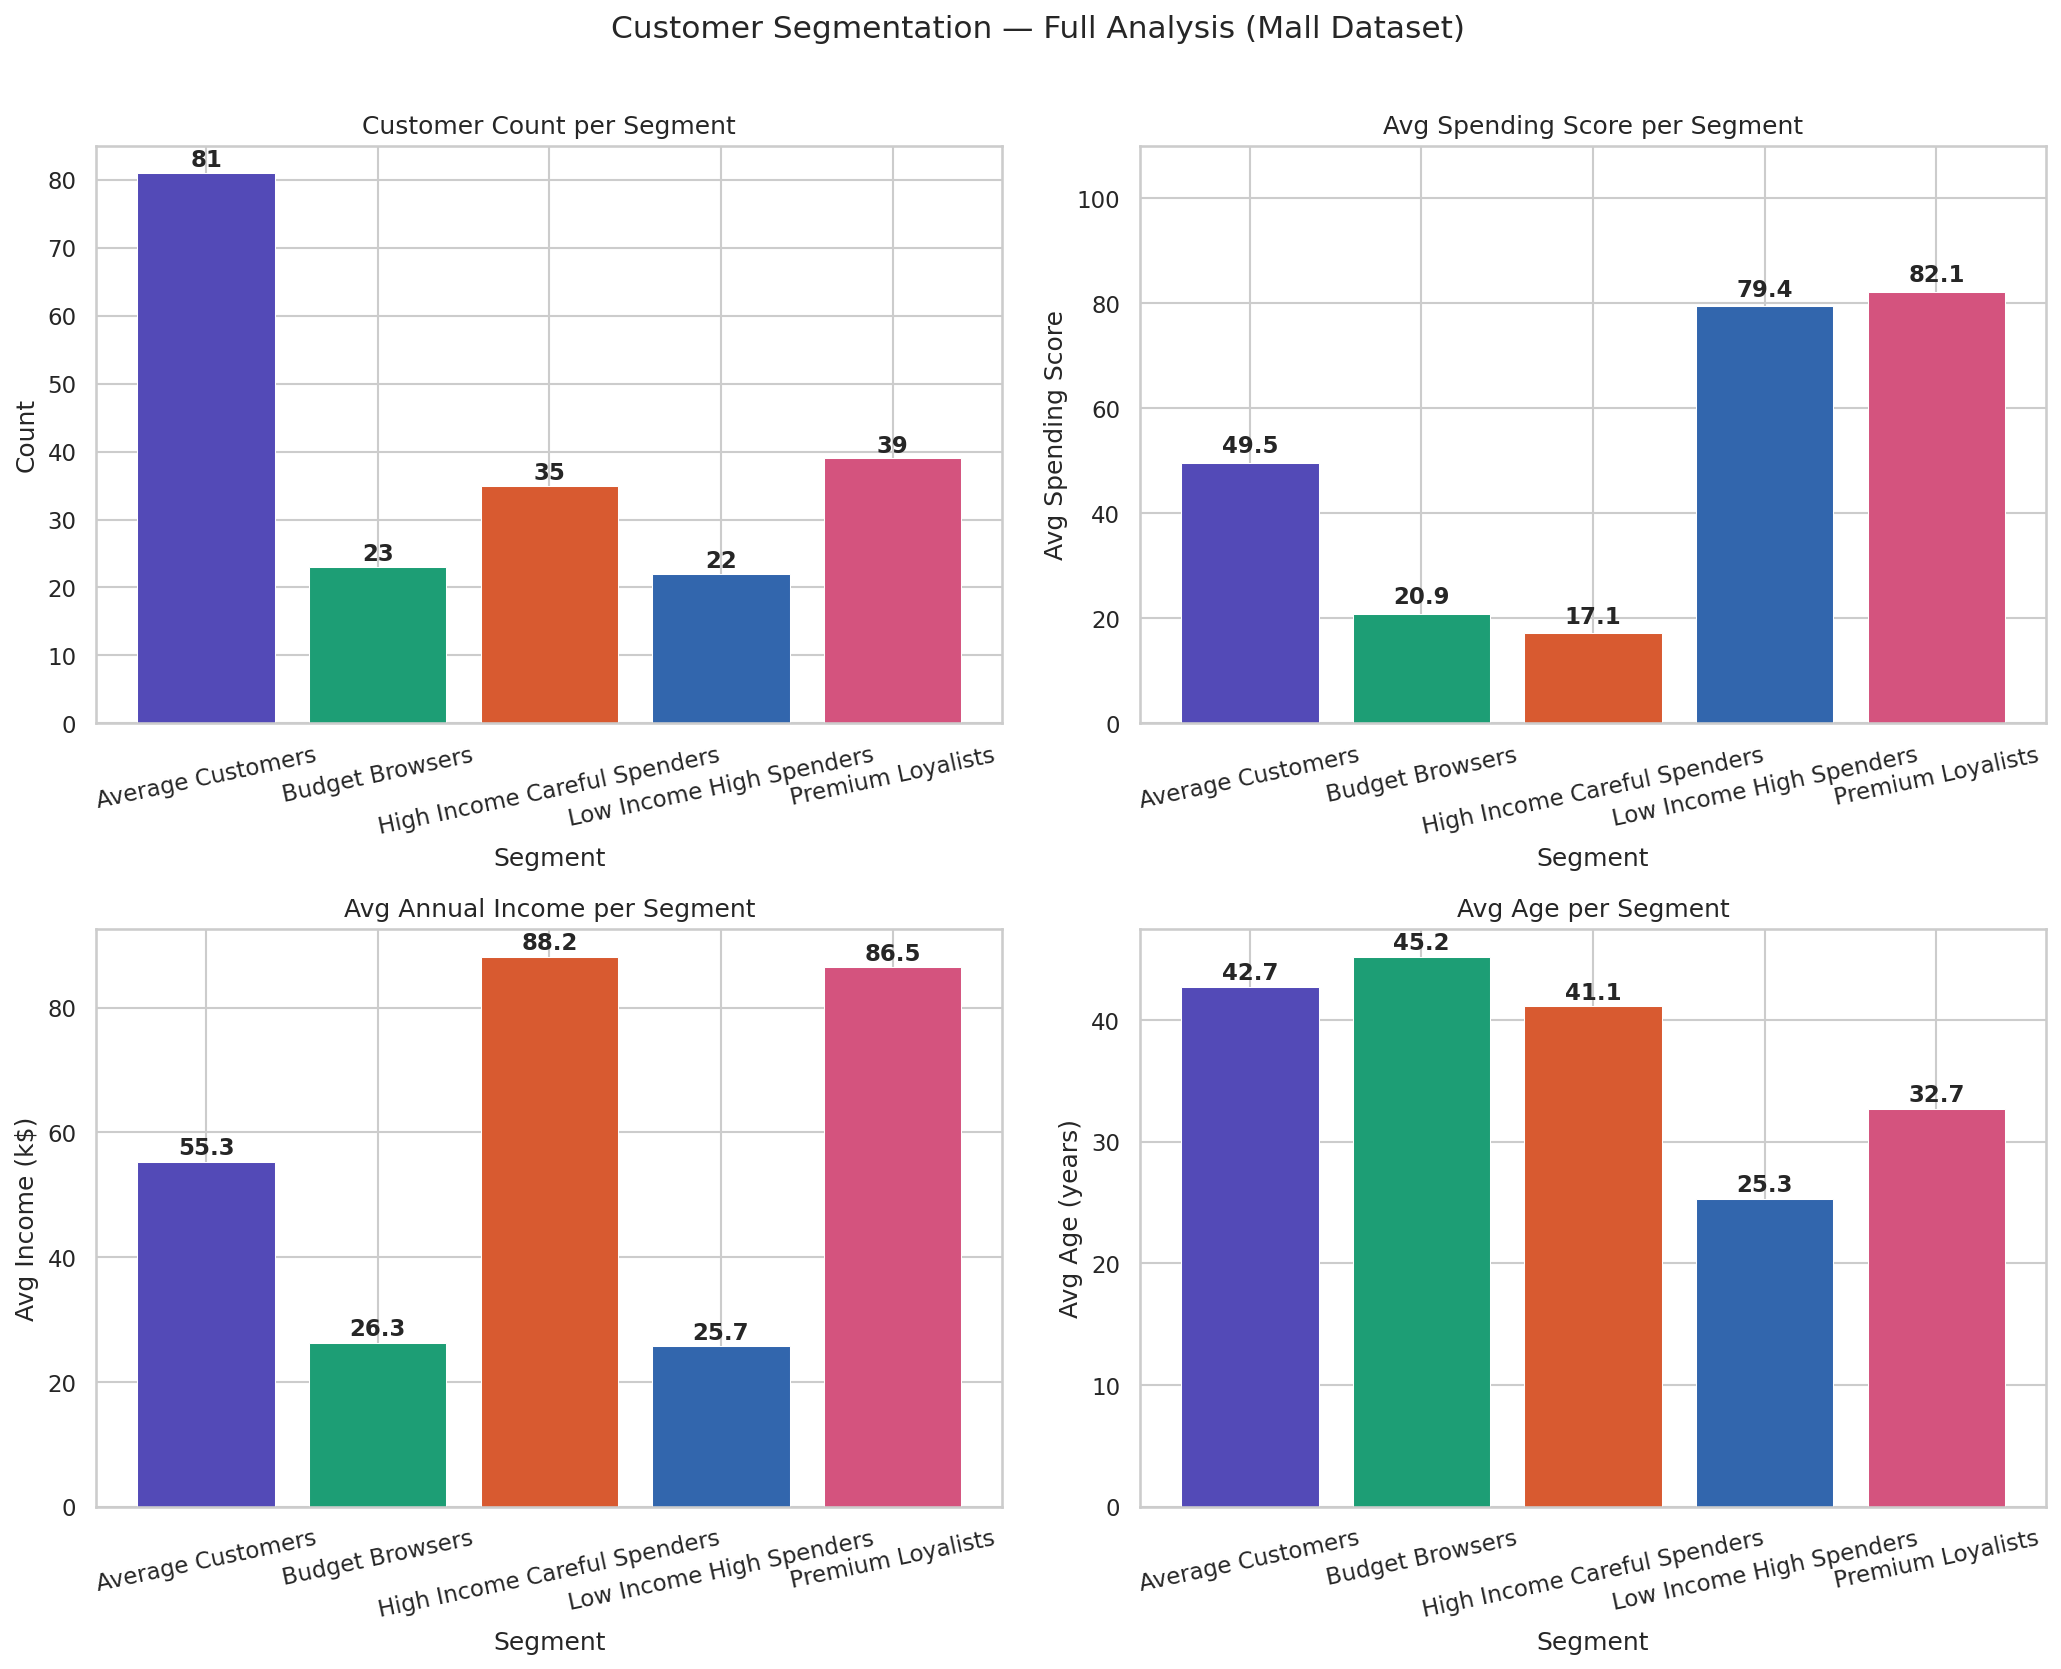

Saved: cluster_analysis.png


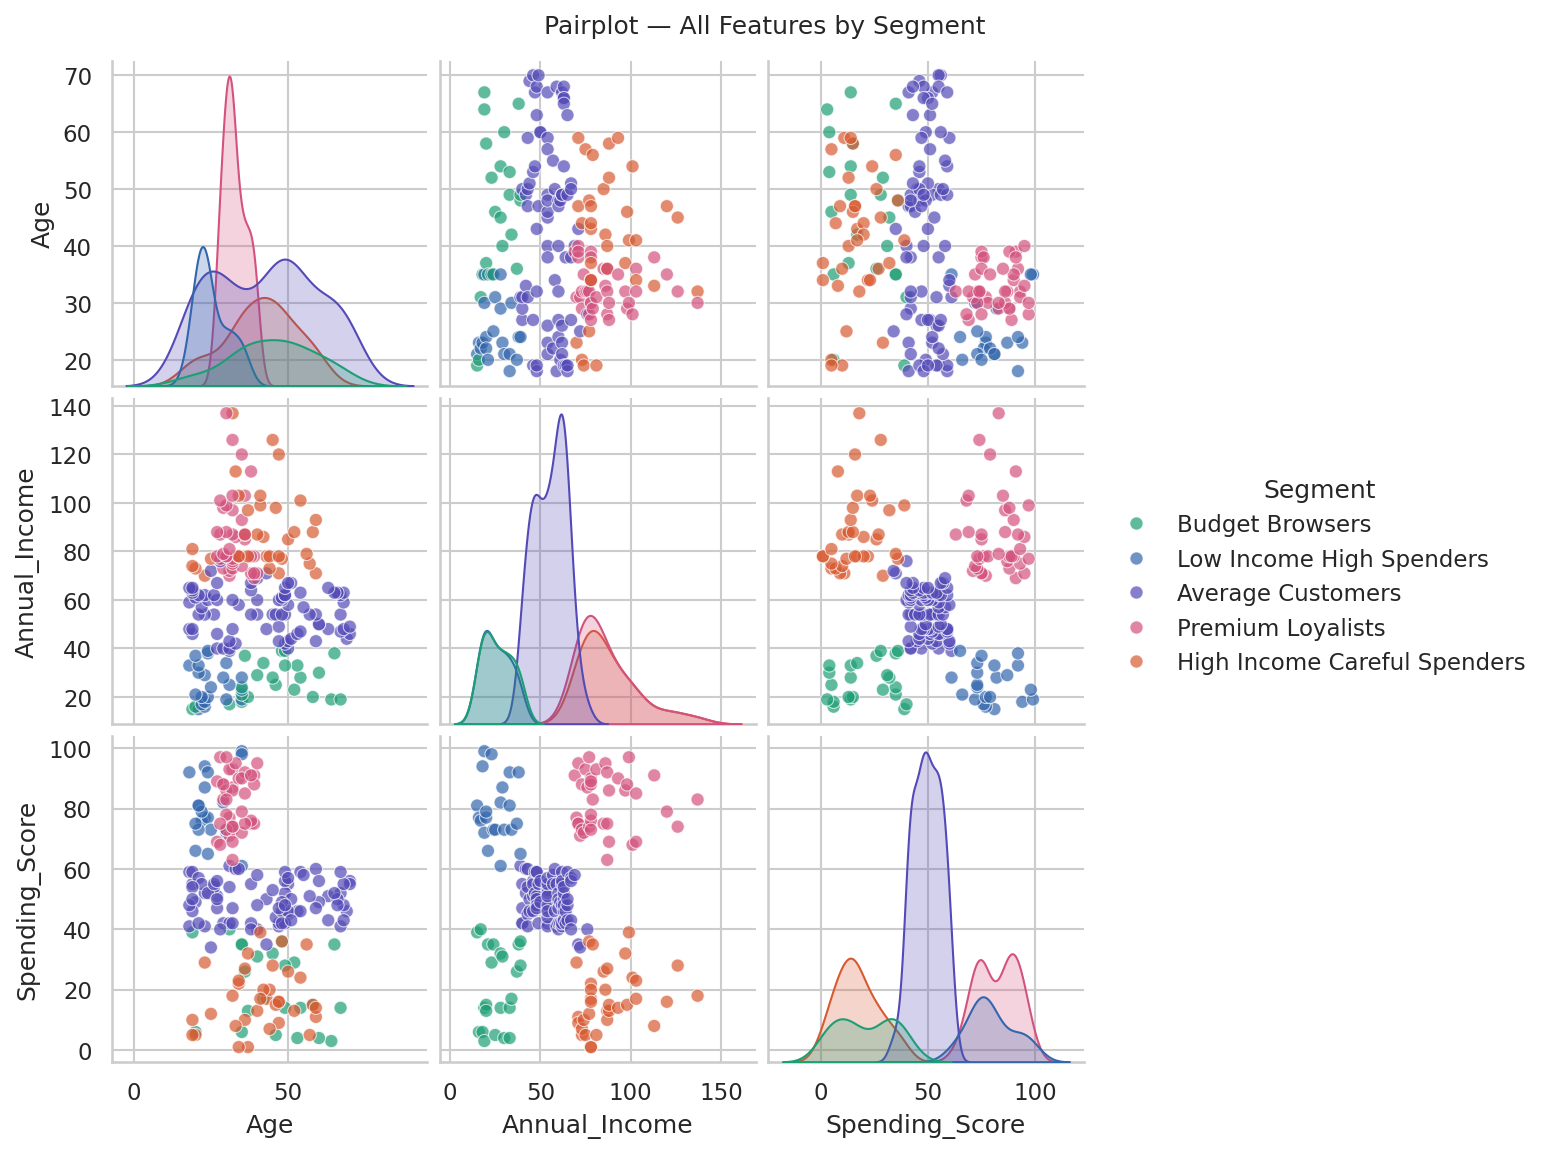

Saved: pairplot.png

   CUSTOMER SEGMENTATION — FINAL REPORT
                              Count  Avg_Age  Avg_Income  Avg_Spending  Female_Pct
Segment                                                                           
Average Customers                81     42.7        55.3          49.5        59.3
Budget Browsers                  23     45.2        26.3          20.9        60.9
High Income Careful Spenders     35     41.1        88.2          17.1        45.7
Low Income High Spenders         22     25.3        25.7          79.4        59.1
Premium Loyalists                39     32.7        86.5          82.1        53.8

--- Business Insights & Marketing Strategy ---

  [Average Customers]
   → Middle segment → Personalised nudges & moderate promotions.

  [Budget Browsers]
   → Low income + low spend → Value bundles, minimal ad spend.

  [High Income Careful Spenders]
   → High earners, low spend → Quality & exclusivity messaging.

  [Low Income High Spenders]
   → Young

In [ ]:
#  Task 04 - Customer Segmentation Analysis
#  CodeNova Internship | K-Means Clustering
#  Dataset: Mall Customer Segmentation Data (Kaggle)
#  https://www.kaggle.com/datasets/vjchoudhary7/
#          customer-segmentation-tutorial-in-python

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

CSV_PATH = "Mall_Customers.csv"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"\n[ERROR] '{CSV_PATH}' not found!\n"
        "Place Mall_Customers.csv in the same folder as this script.\n"
        "Download: https://www.kaggle.com/datasets/vjchoudhary7/"
        "customer-segmentation-tutorial-in-python"
    )

data = pd.read_csv(CSV_PATH)

print("=" * 55)
print("   STEP 1 - Raw Dataset Loaded")
print("=" * 55)
print(f"Original columns: {list(data.columns)}")
print(f"Shape: {data.shape}")

# STEP 2 - Clean & Rename Columns


data.rename(columns={
    'CustomerID':              'CustomerID',
    'Genre':                   'Gender',
    'Age':                     'Age',
    'Annual Income (k$)':      'Annual_Income',
    'Spending Score (1-100)':  'Spending_Score'
}, inplace=True)

# Encode Gender
data['Gender_Encoded'] = (data['Gender'] == 'Male').astype(int)

print("\n" + "=" * 55)
print("   STEP 2 - Preprocessing")
print("=" * 55)
print(f"Cleaned columns: {list(data.columns)}")
print(f"\nFirst 10 rows:")
print(data.head(10).to_string(index=False))
print(f"\nMissing values:\n{data.isnull().sum().to_string()}")
print(f"\nGender distribution:\n{data['Gender'].value_counts().to_string()}")
print(f"\nBasic Statistics:")
print(data[['Age','Annual_Income','Spending_Score']].describe().round(2))

# STEP 3 - Exploratory Data Analysis (EDA)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('EDA — Mall Customer Dataset', fontsize=14)

axes[0].hist(data['Age'], bins=15, color='#534AB7', edgecolor='white', linewidth=0.5)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

axes[1].hist(data['Annual_Income'], bins=15, color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Count')

axes[2].hist(data['Spending_Score'], bins=15, color='#D85A30', edgecolor='white', linewidth=0.5)
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score (1–100)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()
print("\nSaved: eda_distributions.png")

# Gender pie chart
fig, ax = plt.subplots(figsize=(5, 5))
gender_counts = data['Gender'].value_counts()
ax.pie(gender_counts, labels=gender_counts.index,
       autopct='%1.1f%%', colors=['#3266ad', '#D4537E'],
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Gender Distribution')
plt.tight_layout()
plt.savefig('gender_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: gender_distribution.png")

# Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
corr = data[['Age', 'Annual_Income', 'Spending_Score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")

# ─────────────────────────────────────────────────────────────
# STEP 4 - Elbow Method (Income vs Spending Score)
#   This is the standard 2-feature approach for this dataset
#   It clearly gives K=5 clusters
# ─────────────────────────────────────────────────────────────

X = data[['Annual_Income', 'Spending_Score']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia          = []
silhouette_scores = []
K_range          = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Elbow Method — Finding Optimal K', fontsize=14)

axes[0].plot(K_range, inertia, 'o-', color='#534AB7', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='#D85A30', linestyle='--', linewidth=1.5, label='Optimal K=5')
axes[0].set_title('Inertia (WCSS) vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, 's-', color='#1D9E75', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='#D85A30', linestyle='--', linewidth=1.5, label='Optimal K=5')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_method.png', bbox_inches='tight')
plt.show()
print("Saved: elbow_method.png")

best_sil_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest K by Silhouette Score : {best_sil_k}")
print(f"Using K=5 (standard for Mall Customer dataset)")

# ─────────────────────────────────────────────────────────────
# STEP 5 - Apply K-Means with K=5
# ─────────────────────────────────────────────────────────────

OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(X_scaled)

# Get centroids in original scale
centroids_scaled  = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroid_df = pd.DataFrame(centroids_original,
                            columns=['Income_Center', 'Spend_Center'])

# Auto-label each cluster from centroid position
def label_cluster(row):
    inc = row['Income_Center']
    spd = row['Spend_Center']
    if   inc >= 60 and spd >= 60:   return 'Premium Loyalists'
    elif inc <  50 and spd >= 60:   return 'Low Income High Spenders'
    elif inc >= 60 and spd <  50:   return 'High Income Careful Spenders'
    elif inc <  50 and spd <  50:   return 'Budget Browsers'
    else:                            return 'Average Customers'

centroid_df['Segment'] = centroid_df.apply(label_cluster, axis=1)
cluster_to_segment     = centroid_df['Segment'].to_dict()
data['Segment']        = data['Cluster'].map(cluster_to_segment)

print("\n" + "=" * 55)
print(f"   STEP 5 - K-Means Applied (K={OPTIMAL_K})")
print("=" * 55)
print("Cluster Centroids (original scale):")
print(centroid_df[['Income_Center','Spend_Center','Segment']].round(1).to_string())
print("\nSegment Distribution:")
print(data['Segment'].value_counts().to_string())

# ─────────────────────────────────────────────────────────────
# STEP 6 - Visualize Clusters
# ─────────────────────────────────────────────────────────────

COLORS   = ['#534AB7', '#1D9E75', '#D85A30', '#3266ad', '#D4537E']
segments = sorted(data['Segment'].unique())
color_map = {seg: COLORS[i] for i, seg in enumerate(segments)}

# --- Main cluster scatter plot ---
fig, ax = plt.subplots(figsize=(10, 7))
for seg in segments:
    grp = data[data['Segment'] == seg]
    ax.scatter(grp['Annual_Income'], grp['Spending_Score'],
               label=seg, color=color_map[seg], s=80,
               alpha=0.85, edgecolors='white', linewidth=0.6)

# Centroids as black X markers
for _, row in centroid_df.iterrows():
    ax.scatter(row['Income_Center'], row['Spend_Center'],
               color='black', marker='X', s=220, zorder=5)

ax.set_title('Customer Segments — Annual Income vs Spending Score\n(✕ = Cluster Centroid)',
             fontsize=13)
ax.set_xlabel('Annual Income (k$)', fontsize=11)
ax.set_ylabel('Spending Score (1–100)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('cluster_scatter.png', bbox_inches='tight')
plt.show()
print("Saved: cluster_scatter.png")

# --- 4-panel analysis ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Customer Segmentation — Full Analysis (Mall Dataset)',
             fontsize=15, y=1.01)

colors_list = [color_map[s] for s in segments]

# Panel 1: Count
counts = data['Segment'].value_counts().reindex(segments)
bars   = axes[0,0].bar(counts.index, counts.values,
                        color=colors_list, edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Customer Count per Segment')
axes[0,0].set_xlabel('Segment')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=12)
for bar, val in zip(bars, counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.2, str(val),
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

# Panel 2: Avg Spending Score
avg_spend = data.groupby('Segment')['Spending_Score'].mean().reindex(segments)
bars2     = axes[0,1].bar(avg_spend.index, avg_spend.values,
                           color=colors_list, edgecolor='white', linewidth=0.5)
axes[0,1].set_title('Avg Spending Score per Segment')
axes[0,1].set_xlabel('Segment')
axes[0,1].set_ylabel('Avg Spending Score')
axes[0,1].set_ylim(0, 110)
axes[0,1].tick_params(axis='x', rotation=12)
for bar, val in zip(bars2, avg_spend.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   val + 1, f'{val:.1f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

# Panel 3: Avg Income
avg_income = data.groupby('Segment')['Annual_Income'].mean().reindex(segments)
bars3      = axes[1,0].bar(avg_income.index, avg_income.values,
                            color=colors_list, edgecolor='white', linewidth=0.5)
axes[1,0].set_title('Avg Annual Income per Segment')
axes[1,0].set_xlabel('Segment')
axes[1,0].set_ylabel('Avg Income (k$)')
axes[1,0].tick_params(axis='x', rotation=12)
for bar, val in zip(bars3, avg_income.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   val + 0.3, f'{val:.1f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

# Panel 4: Avg Age
avg_age = data.groupby('Segment')['Age'].mean().reindex(segments)
bars4   = axes[1,1].bar(avg_age.index, avg_age.values,
                         color=colors_list, edgecolor='white', linewidth=0.5)
axes[1,1].set_title('Avg Age per Segment')
axes[1,1].set_xlabel('Segment')
axes[1,1].set_ylabel('Avg Age (years)')
axes[1,1].tick_params(axis='x', rotation=12)
for bar, val in zip(bars4, avg_age.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   val + 0.2, f'{val:.1f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_analysis.png', bbox_inches='tight')
plt.show()
print("Saved: cluster_analysis.png")

# --- Pairplot ---
pair_data  = data[['Age','Annual_Income','Spending_Score','Segment']].copy()
palette    = {seg: color_map[seg] for seg in segments}
pair_plot  = sns.pairplot(pair_data, hue='Segment', palette=palette,
                          plot_kws={'alpha': 0.7, 's': 40}, diag_kind='kde')
pair_plot.fig.suptitle('Pairplot — All Features by Segment', y=1.02, fontsize=12)
pair_plot.savefig('pairplot.png', bbox_inches='tight')
plt.show()
print("Saved: pairplot.png")

# ─────────────────────────────────────────────────────────────
# STEP 7 - Final Summary Report
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 55)
print("   CUSTOMER SEGMENTATION — FINAL REPORT")
print("=" * 55)

summary = data.groupby('Segment').agg(
    Count        = ('CustomerID',     'count'),
    Avg_Age      = ('Age',            'mean'),
    Avg_Income   = ('Annual_Income',  'mean'),
    Avg_Spending = ('Spending_Score', 'mean'),
    Female_Pct   = ('Gender_Encoded', lambda x: round((1 - x.mean()) * 100, 1))
).round(1)

print(summary.to_string())

insights = {
    'Premium Loyalists':              'High income + high spend → Loyalty programs & premium offers.',
    'Low Income High Spenders':       'Young impulsive buyers → EMI offers, trend-based campaigns.',
    'High Income Careful Spenders':   'High earners, low spend → Quality & exclusivity messaging.',
    'Budget Browsers':                'Low income + low spend → Value bundles, minimal ad spend.',
    'Average Customers':              'Middle segment → Personalised nudges & moderate promotions.',
}

print("\n--- Business Insights & Marketing Strategy ---")
for seg in segments:
    if seg in insights:
        print(f"\n  [{seg}]")
        print(f"   → {insights[seg]}")

# Save final CSV
data.to_csv('customer_segments_output.csv', index=False)
print("\n\nSaved: customer_segments_output.csv")
print("\nAll outputs saved successfully in your Task 4 folder!")
